In [ ]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import os
from os.path import join
from tqdm.notebook import tqdm

import torch
from torch import nn
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_curve, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

import random
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')


Device: cuda
GPU: Tesla T4


In [ ]:
MONITORED_DIR = '/kaggle/input/datasets/lampdp/masque-300-web'
UNMONITORED_DIR = '/kaggle/input/datasets/lampdp/masque-open-world'
CLOSEDWORLD_CKPT = '/kaggle/input/datasets/lampdp/netcle-res/netclr_checkpoints/netclr_final.pth'

SEQ_LENGTH = 10000
BATCH_SIZE = 128
TEST_SIZE = 0.1

NUM_MONITORED = 300
UNMON_TRAIN_RATIO = 0.5  # giu nguyen split de so sanh, nhung KHONG dung unmon_train de train

print('Open-World (Nearest-Centroid, no retraining) Setup:')
print(f'  Monitored:        {NUM_MONITORED} websites')
print(f'  Closed-world ckpt: {CLOSEDWORLD_CKPT}')
print('  Khong fine-tune, khong train lai - chi load weight + tinh centroid + danh gia')


Open-World (Nearest-Centroid, no retraining) Setup:
  Monitored:        300 websites
  Closed-world ckpt: /kaggle/input/datasets/lampdp/netcle-res/netclr_checkpoints/netclr_final.pth
  Khong fine-tune, khong train lai - chi load weight + tinh centroid + danh gia


In [3]:
# =========================================================
# LOAD DATA
# =========================================================

def load_dir_vectors(data_dir, seq_length, max_classes=None):
    """Load CSV -> direction vectors (SEQ_LENGTH,)"""
    data = {}
    classes = sorted([d for d in os.listdir(data_dir) if os.path.isdir(join(data_dir, d))])
    if max_classes:
        classes = classes[:max_classes]

    for cls_name in tqdm(classes, desc=f'Loading {os.path.basename(data_dir)}'):
        cls_dir = join(data_dir, cls_name)
        files = sorted([f for f in os.listdir(cls_dir) if f.endswith('.csv')])
        samples = []
        for fname in files:
            try:
                df = pd.read_csv(join(cls_dir, fname), sep=';')
                if len(df) < 100: continue
                dirs = np.where(df['direction'].values == 0, -1, 1).astype(np.int8)
                vec = np.zeros(seq_length, dtype=np.int8)
                limit = min(len(dirs), seq_length)
                vec[:limit] = dirs[:limit]
                samples.append(vec)
            except:
                continue
        if samples:
            data[cls_name] = samples
    return data

# 1. Load monitored (300 web) - dung de tinh centroid + closed-world test
print('Loading MONITORED (300 web)...')
mon_data = load_dir_vectors(MONITORED_DIR, SEQ_LENGTH)
mon_classes = sorted(mon_data.keys())
print(f'  {len(mon_classes)} classes, {sum(len(v) for v in mon_data.values())} traces')

mon_label_map = {cls: i for i, cls in enumerate(mon_classes)}
unmon_label = len(mon_classes)   # 300 = "unmonitored"
num_classes = unmon_label + 1    # 301 (chi de tham chieu, model thuc su chi can 300)

# 2. Build monitored arrays + split train/test (train -> centroid, test -> eval)
x_mon, y_mon = [], []
for cls in mon_classes:
    for vec in mon_data[cls]:
        x_mon.append(vec); y_mon.append(mon_label_map[cls])
x_mon = np.array(x_mon, dtype=np.float32)
y_mon = np.array(y_mon, dtype=np.int64)

x_mon_train, x_mon_test, y_mon_train, y_mon_test = train_test_split(
    x_mon, y_mon, test_size=TEST_SIZE, random_state=42, stratify=y_mon)

print(f'Monitored train (centroid pool): {len(y_mon_train)}')
print(f'Monitored test  (eval):          {len(y_mon_test)}')

# 3. Load unmonitored (6000 web) - khong dung de train, chi de eval
print('\nLoading UNMONITORED (6000 web)...')
unmon_data = load_dir_vectors(UNMONITORED_DIR, SEQ_LENGTH)
unmon_classes = sorted(unmon_data.keys())
print(f'  {len(unmon_classes)} classes, {sum(len(v) for v in unmon_data.values())} traces')

# Giu nguyen split unseen de so sanh voi cac lan chay truoc (model chua bao gio thay 50% nay)
np.random.seed(42)
unmon_shuffled = list(unmon_classes)
np.random.shuffle(unmon_shuffled)
split = int(len(unmon_shuffled) * UNMON_TRAIN_RATIO)
unmon_eval_cls = unmon_shuffled[split:]   # unseen half -> dung cho eval

x_unmon = []
for cls in unmon_eval_cls:
    for vec in unmon_data[cls]:
        x_unmon.append(vec)
x_unmon = np.array(x_unmon, dtype=np.float32)
print(f'Unmonitored eval (unseen): {len(x_unmon)} traces tu {len(unmon_eval_cls)} websites')


Loading MONITORED (300 web)...


Loading masque-300-web:   0%|          | 0/300 [00:00<?, ?it/s]

  300 classes, 147840 traces
Monitored train (centroid pool): 133056
Monitored test  (eval):          14784

Loading UNMONITORED (6000 web)...


Loading masque-open-world:   0%|          | 0/6000 [00:00<?, ?it/s]

  6000 classes, 59934 traces
Unmonitored eval (unseen): 29963 traces tu 3000 websites


In [4]:
# =========================================================
# DFNet MODEL (Deep Fingerprinting backbone)
# =========================================================

class DFNet(nn.Module):
    def __init__(self, out_dim):
        super(DFNet, self).__init__()
        kernel_size = 8
        conv_stride = 1
        pool_stride = 4
        pool_size = 8

        self.conv1 = nn.Conv1d(1, 32, kernel_size, stride=conv_stride)
        self.conv1_1 = nn.Conv1d(32, 32, kernel_size, stride=conv_stride)

        self.conv2 = nn.Conv1d(32, 64, kernel_size, stride=conv_stride)
        self.conv2_2 = nn.Conv1d(64, 64, kernel_size, stride=conv_stride)

        self.conv3 = nn.Conv1d(64, 128, kernel_size, stride=conv_stride)
        self.conv3_3 = nn.Conv1d(128, 128, kernel_size, stride=conv_stride)

        self.conv4 = nn.Conv1d(128, 256, kernel_size, stride=conv_stride)
        self.conv4_4 = nn.Conv1d(256, 256, kernel_size, stride=conv_stride)

        self.batch_norm1 = nn.BatchNorm1d(32)
        self.batch_norm2 = nn.BatchNorm1d(64)
        self.batch_norm3 = nn.BatchNorm1d(128)
        self.batch_norm4 = nn.BatchNorm1d(256)

        self.max_pool_1 = nn.MaxPool1d(kernel_size=pool_size, stride=pool_stride)
        self.max_pool_2 = nn.MaxPool1d(kernel_size=pool_size, stride=pool_stride)
        self.max_pool_3 = nn.MaxPool1d(kernel_size=pool_size, stride=pool_stride)
        self.max_pool_4 = nn.MaxPool1d(kernel_size=pool_size, stride=pool_stride)

        self.dropout1 = nn.Dropout(p=0.1)
        self.dropout2 = nn.Dropout(p=0.1)
        self.dropout3 = nn.Dropout(p=0.1)
        self.dropout4 = nn.Dropout(p=0.1)

        self.fc = nn.Linear(10240, out_dim)

    def forward(self, inp):
        x = inp
        # ==== first block ====
        x = F.pad(x, (3, 4)); x = F.elu(self.conv1(x))
        x = F.pad(x, (3, 4)); x = F.elu(self.batch_norm1(self.conv1_1(x)))
        x = F.pad(x, (3, 4)); x = self.max_pool_1(x); x = self.dropout1(x)

        # ==== second block ====
        x = F.pad(x, (3, 4)); x = F.relu(self.conv2(x))
        x = F.pad(x, (3, 4)); x = F.relu(self.batch_norm2(self.conv2_2(x)))
        x = F.pad(x, (3, 4)); x = self.max_pool_2(x); x = self.dropout2(x)

        # ==== third block ====
        x = F.pad(x, (3, 4)); x = F.relu(self.conv3(x))
        x = F.pad(x, (3, 4)); x = F.relu(self.batch_norm3(self.conv3_3(x)))
        x = F.pad(x, (3, 4)); x = self.max_pool_3(x); x = self.dropout3(x)

        # ==== fourth block ====
        x = F.pad(x, (3, 4)); x = F.relu(self.conv4(x))
        x = F.pad(x, (3, 4)); x = F.relu(self.batch_norm4(self.conv4_4(x)))
        x = F.pad(x, (3, 4)); x = self.max_pool_4(x); x = self.dropout4(x)

        x = x.view(x.size(0), -1)   # 10240-dim embedding
        x = self.fc(x)              # classification logits (KHONG dung trong eval nay)
        return x


class DFNetEmbedder(nn.Module):
    """Tra ve embedding 10240-dim TRUOC lop fc."""
    def __init__(self, dfnet):
        super().__init__()
        self.dfnet = dfnet

    def forward(self, x):
        d = self.dfnet
        x = F.pad(x, (3, 4)); x = F.elu(d.conv1(x))
        x = F.pad(x, (3, 4)); x = F.elu(d.batch_norm1(d.conv1_1(x)))
        x = F.pad(x, (3, 4)); x = d.max_pool_1(x); x = d.dropout1(x)

        x = F.pad(x, (3, 4)); x = F.relu(d.conv2(x))
        x = F.pad(x, (3, 4)); x = F.relu(d.batch_norm2(d.conv2_2(x)))
        x = F.pad(x, (3, 4)); x = d.max_pool_2(x); x = d.dropout2(x)

        x = F.pad(x, (3, 4)); x = F.relu(d.conv3(x))
        x = F.pad(x, (3, 4)); x = F.relu(d.batch_norm3(d.conv3_3(x)))
        x = F.pad(x, (3, 4)); x = d.max_pool_3(x); x = d.dropout3(x)

        x = F.pad(x, (3, 4)); x = F.relu(d.conv4(x))
        x = F.pad(x, (3, 4)); x = F.relu(d.batch_norm4(d.conv4_4(x)))
        x = F.pad(x, (3, 4)); x = d.max_pool_4(x); x = d.dropout4(x)

        return x.view(x.size(0), -1)


In [5]:
# =========================================================
# LOAD CLOSED-WORLD CHECKPOINT (300 web) - KHONG TRAIN LAI
# =========================================================

# out_dim chi can dung de khoi tao kien truc cho khop checkpoint;
# fc se khong duoc dung trong danh gia.
model = DFNet(out_dim=NUM_MONITORED).to(device)

checkpoint = torch.load(CLOSEDWORLD_CKPT, map_location=device)

# Checkpoint co the la state_dict thuan cua DFNet, hoac cua DFsimCLR (co prefix 'backbone.')
state_dict = {}
for k, v in checkpoint.items():
    if k.startswith('backbone.'):
        state_dict[k[len('backbone.'):]] = v
    else:
        state_dict[k] = v

log = model.load_state_dict(state_dict, strict=False)
print(f'Loaded closed-world checkpoint.')
print(f'  Missing keys:  {log.missing_keys}')
print(f'  Unexpected keys: {log.unexpected_keys}')

model.eval()
embedder = DFNetEmbedder(model).to(device)
embedder.eval()
print('Encoder (embedding extractor) ready - fc layer ton tai trong checkpoint nhung KHONG duoc dung.')


Loaded closed-world checkpoint.
  Missing keys:  ['fc.weight', 'fc.bias']
  Unexpected keys: ['fc.0.weight', 'fc.0.bias', 'fc.1.weight', 'fc.1.bias', 'fc.1.running_mean', 'fc.1.running_var', 'fc.1.num_batches_tracked', 'fc.3.weight', 'fc.3.bias']
Encoder (embedding extractor) ready - fc layer ton tai trong checkpoint nhung KHONG duoc dung.


In [6]:
# =========================================================
# TINH CENTROID TU TAP TRAIN CUA 300-WEB (closed-world)
# =========================================================
print('Computing centroids from monitored train set...')

centroid_sums = {}
centroid_counts = {}

with torch.no_grad():
    for i in tqdm(range(0, len(x_mon_train), 64), desc='Centroids'):
        batch_x = x_mon_train[i:i+64]
        batch_y = y_mon_train[i:i+64]
        data = torch.from_numpy(batch_x).view(len(batch_x), 1, -1).float().to(device)
        emb = embedder(data).cpu().numpy()

        for j, lbl in enumerate(batch_y):
            if lbl not in centroid_sums:
                centroid_sums[lbl] = np.zeros(emb.shape[1], dtype=np.float64)
                centroid_counts[lbl] = 0
            centroid_sums[lbl] += emb[j]
            centroid_counts[lbl] += 1

        del data, emb
        if i % 6400 == 0:
            torch.cuda.empty_cache()

centroids = np.zeros((NUM_MONITORED, list(centroid_sums.values())[0].shape[0]), dtype=np.float64)
for c in range(NUM_MONITORED):
    if c in centroid_sums and centroid_counts[c] > 0:
        cent = centroid_sums[c] / centroid_counts[c]
        cent = cent / (np.linalg.norm(cent) + 1e-8)
        centroids[c] = cent

print(f'{NUM_MONITORED} centroids computed (dim={centroids.shape[1]})')


Computing centroids from monitored train set...


Centroids:   0%|          | 0/2079 [00:00<?, ?it/s]

300 centroids computed (dim=10240)


In [7]:
# =========================================================
# FORWARD OPEN-WORLD DATA QUA ENCODER (1 lan, khong train lai)
# Test set = monitored test (closed-world) + unmonitored unseen
# =========================================================

def compute_embeddings(x_arr, batch_size=64, desc='Embeddings'):
    all_emb = []
    with torch.no_grad():
        for i in tqdm(range(0, len(x_arr), batch_size), desc=desc):
            batch_x = x_arr[i:i+batch_size]
            data = torch.from_numpy(batch_x).view(len(batch_x), 1, -1).float().to(device)
            emb = embedder(data).cpu().numpy()
            all_emb.append(emb)
            del data, emb
            if i % 6400 == 0:
                torch.cuda.empty_cache()
    return np.concatenate(all_emb)

print('Computing embeddings for monitored test set...')
emb_mon_test = compute_embeddings(x_mon_test, desc='Mon test emb')

print('Computing embeddings for unmonitored (unseen) set...')
emb_unmon = compute_embeddings(x_unmon, desc='Unmon emb')

# Normalize + cosine similarity voi centroids
def cos_dist_and_pred(emb, centroids):
    emb_norm = emb / (np.linalg.norm(emb, axis=1, keepdims=True) + 1e-8)
    sim = emb_norm @ centroids.T          # (N, 300)
    max_sim = np.max(sim, axis=1)
    nearest = np.argmax(sim, axis=1)      # class du doan neu KHONG bi danh gia la unmonitored
    cos_dist = 1 - max_sim
    return cos_dist, nearest

cos_dist_mon, nearest_mon = cos_dist_and_pred(emb_mon_test, centroids)
cos_dist_unmon, nearest_unmon = cos_dist_and_pred(emb_unmon, centroids)

all_cos_dist = np.concatenate([cos_dist_mon, cos_dist_unmon])
all_nearest = np.concatenate([nearest_mon, nearest_unmon])
y_true_bin = np.concatenate([np.zeros(len(cos_dist_mon)), np.ones(len(cos_dist_unmon))]).astype(int)
y_true_mon_classes = y_mon_test  # ground-truth class cho phan monitored

print(f'Test: {len(cos_dist_mon)} monitored + {len(cos_dist_unmon)} unmonitored = {len(all_cos_dist)} total')


Computing embeddings for monitored test set...


Mon test emb:   0%|          | 0/231 [00:00<?, ?it/s]

Computing embeddings for unmonitored (unseen) set...


Unmon emb:   0%|          | 0/469 [00:00<?, ?it/s]

Test: 14784 monitored + 29963 unmonitored = 44747 total


OPEN-WORLD DETECTION (Nearest-Centroid Distance)
Threshold (cos_dist >= t -> unmonitored): t = 0.0389
TP=29936, FP=14713, TN=71, FN=27
Accuracy:  0.6706
Recall:    0.9991  (29936/29963 unmon detected)
Precision: 0.6705
F1:        0.8024
AUC-ROC:   0.5935

CLOSED-WORLD ACCURACY (nearest-centroid, 300 classes)
Nearest-centroid accuracy (chi mon test, bo qua threshold): 0.6839

OVERALL 301-WAY ACCURACY (nearest-centroid + threshold)
Overall accuracy: 0.6703


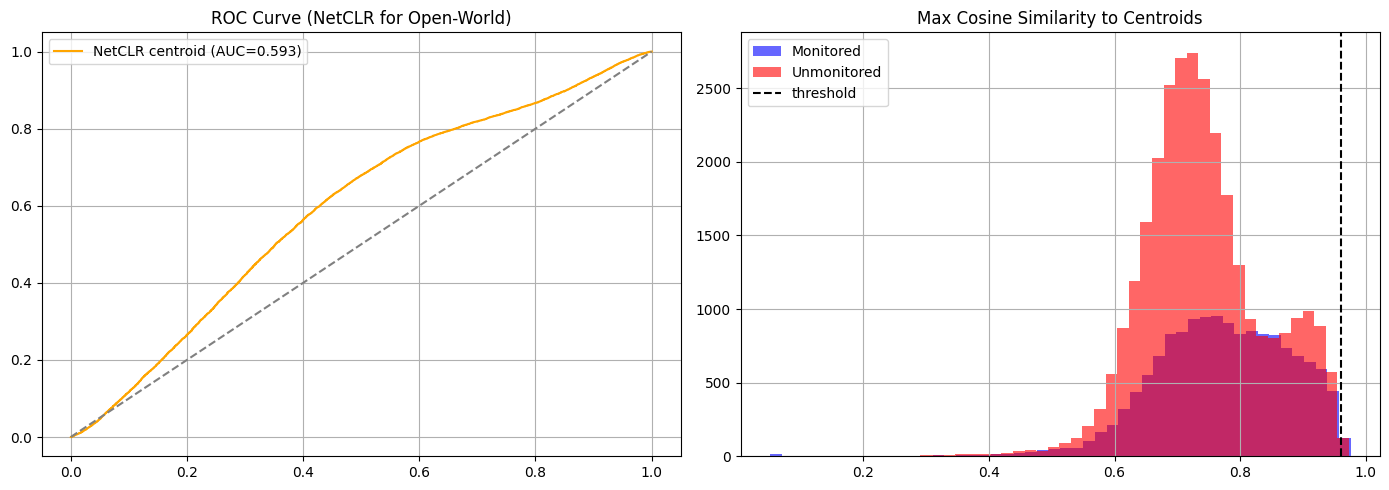


SUMMARY - NetCLR Nearest-Centroid Open-World
Metric                              Value     
---------------------------------------------
Open-world Accuracy                 0.6706    
Open-world Recall                   0.9991    
Open-world Precision                0.6705    
Open-world F1                       0.8024    
Open-world AUC                      0.5935    
Closed-world Acc (nearest-centroid) 0.6839    
Overall 301-way Acc                 0.6703    

Done!


In [8]:
# =========================================================
# TIM THRESHOLD (toi uu F1 cho bai toan binary mon/unmon)
# =========================================================
prec, rec, thr = precision_recall_curve(y_true_bin, all_cos_dist)
f1 = 2 * prec * rec / (prec + rec + 1e-8)
best_idx = np.argmax(f1)
THRESHOLD = thr[best_idx] if best_idx < len(thr) else 0.5

pred_bin = (all_cos_dist >= THRESHOLD).astype(int)
tp = np.sum((pred_bin==1)&(y_true_bin==1))
fp = np.sum((pred_bin==1)&(y_true_bin==0))
tn = np.sum((pred_bin==0)&(y_true_bin==0))
fn = np.sum((pred_bin==0)&(y_true_bin==1))

acc_bin = (tp+tn)/len(y_true_bin)
tpr = tp/(tp+fn) if (tp+fn)>0 else 0
fpr = fp/(fp+tn) if (fp+tn)>0 else 0
prec_bin = tp/(tp+fp) if (tp+fp)>0 else 0
try:
    auc = roc_auc_score(y_true_bin, all_cos_dist)
except:
    auc = 0

print('='*60)
print('OPEN-WORLD DETECTION (Nearest-Centroid Distance)')
print('='*60)
print(f'Threshold (cos_dist >= t -> unmonitored): t = {THRESHOLD:.4f}')
print(f'TP={tp}, FP={fp}, TN={tn}, FN={fn}')
print(f'Accuracy:  {acc_bin:.4f}')
print(f'Recall:    {tpr:.4f}  ({tp}/{tp+fn} unmon detected)')
print(f'Precision: {prec_bin:.4f}')
print(f'F1:        {f1[best_idx]:.4f}')
print(f'AUC-ROC:   {auc:.4f}')

# =========================================================
# CLOSED-WORLD CLASSIFICATION (Nearest-Centroid, KHONG dung fc)
# Chi tinh tren cac mau monitored, va CHI tinh tren mau duoc
# du doan dung la 'monitored' (pred_bin==0) -> nearest centroid
# Hoac: ep gan vao centroid gan nhat bat ke threshold (de so sanh
# voi kha nang phan biet website cua embedding)
# =========================================================
nearest_mon_pred = all_nearest[:len(cos_dist_mon)]
cw_acc_nearest = accuracy_score(y_true_mon_classes, nearest_mon_pred)
print('\n' + '='*60)
print('CLOSED-WORLD ACCURACY (nearest-centroid, 300 classes)')
print('='*60)
print(f'Nearest-centroid accuracy (chi mon test, bo qua threshold): {cw_acc_nearest:.4f}')

# =========================================================
# OVERALL 301-WAY: ket hop ca 2 buoc quyet dinh
#   pred = unmonitored (300)  neu cos_dist >= threshold
#   pred = nearest centroid (0..299) neu cos_dist < threshold
# =========================================================
final_pred = np.where(pred_bin == 1, unmon_label, all_nearest)
y_true_full = np.concatenate([y_true_mon_classes, np.full(len(cos_dist_unmon), unmon_label)])
overall_acc = accuracy_score(y_true_full, final_pred)

print('\n' + '='*60)
print('OVERALL 301-WAY ACCURACY (nearest-centroid + threshold)')
print('='*60)
print(f'Overall accuracy: {overall_acc:.4f}')

# =========================================================
# PLOTS
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

try:
    fpr_arr, tpr_arr, _ = roc_curve(y_true_bin, all_cos_dist)
    axes[0].plot(fpr_arr, tpr_arr, color='orange', label=f'NetCLR centroid (AUC={auc:.3f})')
    axes[0].plot([0,1],[0,1],'--',color='gray')
    axes[0].set_title('ROC Curve (NetCLR for Open-World)'); axes[0].legend(); axes[0].grid(True)
except: pass

axes[1].hist(1 - cos_dist_mon, bins=50, alpha=0.6, label='Monitored', color='blue')
axes[1].hist(1 - cos_dist_unmon, bins=50, alpha=0.6, label='Unmonitored', color='red')
axes[1].axvline(1 - THRESHOLD, color='black', linestyle='--', label='threshold')
axes[1].set_title('Max Cosine Similarity to Centroids'); axes[1].legend(); axes[1].grid(True)

plt.tight_layout(); plt.savefig('netclr_centroid_openworld.png', dpi=150); plt.show()

# =========================================================
# SUMMARY
# =========================================================
print('\n' + '='*60)
print('SUMMARY - NetCLR Nearest-Centroid Open-World')
print('='*60)
print(f'{"Metric":<35} {"Value":<10}')
print('-'*45)
print(f'{"Open-world Accuracy":<35} {acc_bin:<10.4f}')
print(f'{"Open-world Recall":<35} {tpr:<10.4f}')
print(f'{"Open-world Precision":<35} {prec_bin:<10.4f}')
print(f'{"Open-world F1":<35} {f1[best_idx]:<10.4f}')
print(f'{"Open-world AUC":<35} {auc:<10.4f}')
print(f'{"Closed-world Acc (nearest-centroid)":<35} {cw_acc_nearest:<10.4f}')
print(f'{"Overall 301-way Acc":<35} {overall_acc:<10.4f}')
print('\nDone!')
